# 04 Light. Advanced Models & Two-Stage Re-Ranking


Основная идея сохраняется:  
**Candidate Generation → CatBoost Re-ranking → Top-10 recommendations**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

K = 10

# LIGHT SETTINGS
RANKER_TRAIN_USERS = 1000
EVAL_N_USERS_ADVANCED = 500
CATBOOST_ITERATIONS = 50

N_POP_CANDIDATES = 30
N_ALS_CANDIDATES = 30
N_COLD_AWARE_CANDIDATES = 30
N_CONTENT_CANDIDATES = 30

RUN_BERT = False
RUN_RANKER = True

pd.set_option("display.max_columns", 120)

## 1. Загрузка processed-файлов

In [ ]:
items_path = "/content/drive/MyDrive/items_processed.csv"
users_path = "/content/drive/MyDrive/users_processed.csv"
interactions_path = "/content/drive/MyDrive/interactions_processed.csv"

items = pd.read_csv(items_path)
users = pd.read_csv(users_path)
interactions = pd.read_csv(interactions_path, parse_dates=["last_watch_dt"])

print("items:", items.shape)
print("users:", users.shape)
print("interactions:", interactions.shape)

display(items.head())
display(users.head())
display(interactions.head())

items: (15963, 14)
users: (441316, 5)
interactions: (5476251, 5)


,item_id,content_type,title,title_orig,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords,release_year_cat
0,10711,film,поговори с ней,Hable con ella,"драмы, зарубежные, детективы, мелодрамы",испания,False,16.0,unknown,педро альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ...",2000-2010
1,2508,film,голые перцы,Search Party,"зарубежные, приключения, комедии",сша,False,16.0,unknown,скот армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео...",2010-2020
2,10716,film,тактическая сила,Tactical Force,"криминал, зарубежные, триллеры, боевики, комедии",канада,False,16.0,unknown,адам п. калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг...",2010-2020
3,7868,film,45 лет,45 Years,"драмы, зарубежные, мелодрамы",великобритания,False,16.0,unknown,эндрю хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю...",2010-2020
4,16268,film,все решает мгновение,NaN,"драмы, спорт, советские, мелодрамы",ссср,False,12.0,ленфильм,виктор садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж...",1970-1980


,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,M,True
1,962099,age_18_24,income_20_40,M,False
2,1047345,age_45_54,income_40_60,F,False
3,721985,age_45_54,income_20_40,F,False
4,704055,age_35_44,income_60_90,F,False


,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72
1,699317,1659,2021-05-29,8317,100
2,656683,7107,2021-05-09,10,0
3,864613,7638,2021-07-05,14483,100
4,964868,9506,2021-04-30,6725,100


## 2. Подготовка, time split и cold-start сегменты

In [ ]:
items["item_id"] = items["item_id"].astype(int)
users["user_id"] = users["user_id"].astype(int)
interactions["user_id"] = interactions["user_id"].astype(int)
interactions["item_id"] = interactions["item_id"].astype(int)

if not np.issubdtype(interactions["last_watch_dt"].dtype, np.datetime64):
    interactions["last_watch_dt"] = pd.to_datetime(interactions["last_watch_dt"])

if "watched_pct" not in interactions.columns:
    interactions["watched_pct"] = 0
if "total_dur" not in interactions.columns:
    interactions["total_dur"] = 0

interactions["watched_pct"] = interactions["watched_pct"].fillna(0).astype(float)
interactions["total_dur"] = interactions["total_dur"].fillna(0).astype(float)

if "interaction_score" not in interactions.columns:
    max_dur = interactions["total_dur"].max()
    if max_dur > 0:
        interactions["interaction_score"] = (
            0.7 * interactions["watched_pct"] / 100
            + 0.3 * np.log1p(interactions["total_dur"]) / np.log1p(max_dur)
        )
    else:
        interactions["interaction_score"] = interactions["watched_pct"] / 100

interactions["interaction_score"] = interactions["interaction_score"].fillna(0)

interactions = (
    interactions
    .sort_values("last_watch_dt")
    .groupby(["user_id", "item_id"], as_index=False)
    .agg({
        "last_watch_dt": "max",
        "watched_pct": "max",
        "total_dur": "max",
        "interaction_score": "max"
    })
)

split_date = interactions["last_watch_dt"].quantile(0.8)
train = interactions[interactions["last_watch_dt"] <= split_date].copy()
test = interactions[interactions["last_watch_dt"] > split_date].copy()

print("Split date:", split_date)
print("train:", train.shape, "users:", train["user_id"].nunique(), "items:", train["item_id"].nunique())
print("test:", test.shape, "users:", test["user_id"].nunique(), "items:", test["item_id"].nunique())

train_items = set(train["item_id"].unique())
test_items = set(test["item_id"].unique())
cold_items = list(test_items - train_items)
cold_item_set = set(cold_items)

print("Cold items:", len(cold_items))
print("Cold item share:", round(len(cold_items) / test["item_id"].nunique() * 100, 2), "%")

train_users = set(train["user_id"].unique())
test_users = set(test["user_id"].unique())

full_cold_users = list(test_users - train_users)

user_hist = train.groupby("user_id").size().reset_index(name="n_interactions")
test_user_set = set(test["user_id"].unique())

very_cold_users = user_hist[user_hist["n_interactions"] <= 2]["user_id"].tolist()
semi_cold_users = user_hist[(user_hist["n_interactions"] >= 3) & (user_hist["n_interactions"] <= 5)]["user_id"].tolist()
medium_users = user_hist[(user_hist["n_interactions"] >= 6) & (user_hist["n_interactions"] <= 9)]["user_id"].tolist()
warm_users = user_hist[user_hist["n_interactions"] >= 10]["user_id"].tolist()

very_cold_users = [u for u in very_cold_users if u in test_user_set]
semi_cold_users = [u for u in semi_cold_users if u in test_user_set]
medium_users = [u for u in medium_users if u in test_user_set]
warm_users = [u for u in warm_users if u in test_user_set]

segments = {
    "full_cold_0": full_cold_users,
    "very_cold_1_2": very_cold_users,
    "semi_cold_3_5": semi_cold_users,
    "medium_6_9": medium_users,
    "warm_10_plus": warm_users,
}

segment_stats = pd.DataFrame({
    "segment": list(segments.keys()),
    "n_users": [len(v) for v in segments.values()]
})
segment_stats["share_of_test_users"] = segment_stats["n_users"] / test["user_id"].nunique()

display(segment_stats)

Split date: 2021-08-04 00:00:00
train: (4423600, 6) users: 819309 items: 15331
test: (1052651, 6) users: 312327 items: 8863
Cold items: 375
Cold item share: 4.23 %


,segment,n_users,share_of_test_users
0,full_cold_0,142870,0.457437
1,very_cold_1_2,46344,0.148383
2,semi_cold_3_5,38243,0.122445
3,medium_6_9,28614,0.091616
4,warm_10_plus,56256,0.180119


## 3. Метрики

In [ ]:
def precision_at_k(recs, true_items, k=10):
    recs = recs[:k]
    true_items = set(true_items)

    if len(recs) == 0:
        return 0.0

    return len(set(recs) & true_items) / k


def recall_at_k(recs, true_items, k=10):
    recs = recs[:k]
    true_items = set(true_items)

    if len(true_items) == 0:
        return 0.0

    return len(set(recs) & true_items) / len(true_items)


def f1_at_k(recs, true_items, k=10):
    p = precision_at_k(recs, true_items, k)
    r = recall_at_k(recs, true_items, k)

    if p + r == 0:
        return 0.0

    return 2 * p * r / (p + r)


def average_precision_at_k(recs, true_items, k=10):
    recs = recs[:k]
    true_items = set(true_items)

    if len(true_items) == 0:
        return 0.0

    score = 0.0
    hits = 0

    for i, item_id in enumerate(recs, start=1):
        if item_id in true_items:
            hits += 1
            score += hits / i

    return score / min(len(true_items), k)


def dcg_at_k(recs, true_items, k=10):
    recs = recs[:k]
    true_items = set(true_items)

    dcg = 0.0

    for i, item_id in enumerate(recs, start=1):
        rel = 1 if item_id in true_items else 0
        dcg += rel / np.log2(i + 1)

    return dcg


def ndcg_at_k(recs, true_items, k=10):

    true_items = set(true_items)

    if len(true_items) == 0:
        return 0.0

    dcg = dcg_at_k(recs, true_items, k)

    ideal_hits = min(len(true_items), k)
    idcg = sum(1 / np.log2(i + 1) for i in range(1, ideal_hits + 1))

    if idcg == 0:
        return 0.0

    return dcg / idcg


def evaluate_model(recommend_func, test_df, users_sample, k=10):
    test_grouped = test_df.groupby("user_id")["item_id"].apply(list).to_dict()

    precisions = []
    recalls = []
    f1s = []
    maps = []
    ndcgs = []

    for user_id in users_sample:
        if user_id not in test_grouped:
            continue

        true_items = test_grouped[user_id]
        recs = recommend_func(user_id, k=k)

        precisions.append(precision_at_k(recs, true_items, k))
        recalls.append(recall_at_k(recs, true_items, k))
        f1s.append(f1_at_k(recs, true_items, k))
        maps.append(average_precision_at_k(recs, true_items, k))
        ndcgs.append(ndcg_at_k(recs, true_items, k))

    return {
        f"precision@{k}": np.mean(precisions) if len(precisions) else np.nan,
        f"recall@{k}": np.mean(recalls) if len(recalls) else np.nan,
        f"f1@{k}": np.mean(f1s) if len(f1s) else np.nan,
        f"map@{k}": np.mean(maps) if len(maps) else np.nan,
        f"ndcg@{k}": np.mean(ndcgs) if len(ndcgs) else np.nan,
        "n_users": len(precisions)
    }


def get_eval_sample(users_list, n=5000, seed=42):
    rng = np.random.default_rng(seed)
    users_list = np.array(list(users_list))

    if len(users_list) == 0:
        return []

    if len(users_list) <= n:
        return list(users_list)

    return list(rng.choice(users_list, size=n, replace=False))

## 4. Popularity, TF-IDF, Hybrid и Cold-Aware Hybrid

In [ ]:
popular_items = train.groupby("item_id").size().sort_values(ascending=False).index.tolist()
user_train_items = train.groupby("user_id")["item_id"].apply(set).to_dict()

def recommend_popularity(user_id, k=10):
    seen = user_train_items.get(user_id, set())
    recs = []
    for item_id in popular_items:
        if item_id not in seen:
            recs.append(item_id)
        if len(recs) >= k:
            break
    return recs

if "item_text" not in items.columns:
    text_cols = [
        "title", "title_orig", "genres", "countries", "studios",
        "directors", "actors", "description", "keywords",
        "release_year_cat", "content_type"
    ]
    for col in text_cols:
        if col not in items.columns:
            items[col] = ""
        else:
            items[col] = items[col].astype("object")
        items[col] = items[col].where(items[col].notna(), "").astype(str)

    items["item_text"] = items[text_cols].agg(" ".join, axis=1)

item_id_to_idx = dict(zip(items["item_id"], range(len(items))))
idx_to_item_id = dict(zip(range(len(items)), items["item_id"]))

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)
item_tfidf = tfidf.fit_transform(items["item_text"].fillna("").astype(str))

print("TF-IDF matrix:", item_tfidf.shape)

def build_user_tfidf_profile(user_id):
    hist = train[train["user_id"] == user_id]
    if hist.empty:
        return None

    idxs, weights = [], []
    for _, row in hist.iterrows():
        item_id = row["item_id"]
        if item_id in item_id_to_idx:
            idxs.append(item_id_to_idx[item_id])
            weights.append(row["interaction_score"])

    if len(idxs) == 0:
        return None

    weights = np.array(weights)
    profile = item_tfidf[idxs].multiply(weights.reshape(-1, 1)).sum(axis=0)
    profile = normalize(np.asarray(profile))
    return profile

def recommend_tfidf_content(user_id, k=10):
    profile = build_user_tfidf_profile(user_id)
    if profile is None:
        return recommend_popularity(user_id, k)

    seen = user_train_items.get(user_id, set())
    scores = cosine_similarity(profile, item_tfidf).ravel()
    ranked_idx = np.argsort(-scores)

    recs = []
    for idx in ranked_idx:
        item_id = idx_to_item_id[idx]
        if item_id not in seen:
            recs.append(item_id)
        if len(recs) >= k:
            break

    return recs

item_popularity = np.log1p(train.groupby("item_id").size())

pop_score = pd.Series(0, index=items["item_id"])
pop_score.loc[item_popularity.index] = item_popularity

if pop_score.max() > 0:
    pop_score = pop_score / pop_score.max()

item_pop_score_array = items["item_id"].map(pop_score).fillna(0).values
item_pop_dict = dict(zip(items["item_id"], item_pop_score_array))

def recommend_hybrid_content_popularity(user_id, k=10, alpha=0.7):
    profile = build_user_tfidf_profile(user_id)
    if profile is None:
        return recommend_popularity(user_id, k)

    seen = user_train_items.get(user_id, set())
    content_scores = cosine_similarity(profile, item_tfidf).ravel()
    scores = alpha * content_scores + (1 - alpha) * item_pop_score_array
    ranked_idx = np.argsort(-scores)

    recs = []
    for idx in ranked_idx:
        item_id = idx_to_item_id[idx]
        if item_id not in seen:
            recs.append(item_id)
        if len(recs) >= k:
            break
    return recs

def recommend_cold_aware_hybrid(user_id, k=10, alpha_warm=0.6, alpha_cold_item=0.95):
    profile = build_user_tfidf_profile(user_id)
    if profile is None:
        return recommend_popularity(user_id, k)

    seen = user_train_items.get(user_id, set())
    content_scores = cosine_similarity(profile, item_tfidf).ravel()

    alpha_array = np.full(len(items), alpha_warm)
    for item_id in cold_item_set:
        if item_id in item_id_to_idx:
            alpha_array[item_id_to_idx[item_id]] = alpha_cold_item

    scores = alpha_array * content_scores + (1 - alpha_array) * item_pop_score_array
    ranked_idx = np.argsort(-scores)

    recs = []
    for idx in ranked_idx:
        item_id = idx_to_item_id[idx]
        if item_id not in seen:
            recs.append(item_id)
        if len(recs) >= k:
            break
    return recs

TF-IDF matrix: (15963, 30000)


## 5. ALS как источник кандидатов

In [ ]:
try:
    import implicit

    user_ids = train["user_id"].unique()
    item_ids = items["item_id"].unique()

    user_to_idx = {u: i for i, u in enumerate(user_ids)}
    item_to_idx_als = {i: j for j, i in enumerate(item_ids)}
    idx_to_item_als = {j: i for i, j in item_to_idx_als.items()}

    train_als = train[
        train["user_id"].isin(user_to_idx) &
        train["item_id"].isin(item_to_idx_als)
    ].copy()

    rows_als = train_als["user_id"].map(user_to_idx)
    cols_als = train_als["item_id"].map(item_to_idx_als)
    values_als = train_als["interaction_score"].astype(float)

    user_item_matrix = csr_matrix(
        (values_als, (rows_als, cols_als)),
        shape=(len(user_to_idx), len(item_to_idx_als))
    )

    als_model = implicit.als.AlternatingLeastSquares(
        factors=32,
        regularization=0.05,
        iterations=10,
        random_state=RANDOM_STATE
    )

    als_model.fit(user_item_matrix)

    ALS_AVAILABLE = True
    print("ALS trained.")

except Exception as e:
    ALS_AVAILABLE = False
    print("ALS skipped:", e)

def recommend_als(user_id, k=10):
    if not ALS_AVAILABLE or user_id not in user_to_idx:
        return recommend_popularity(user_id, k)

    user_idx = user_to_idx[user_id]

    recs, scores = als_model.recommend(
        userid=user_idx,
        user_items=user_item_matrix[user_idx],
        N=k,
        filter_already_liked_items=True
    )

    return [idx_to_item_als[i] for i in recs]

def get_als_score(user_id, item_id):
    if not ALS_AVAILABLE:
        return 0.0
    if user_id not in user_to_idx or item_id not in item_to_idx_als:
        return 0.0

    uidx = user_to_idx[user_id]
    iidx = item_to_idx_als[item_id]

    try:
        return float(als_model.user_factors[uidx] @ als_model.item_factors[iidx])
    except Exception:
        return 0.0

  0%|          | 0/10 [00:00<?, ?it/s]

ALS trained.


## 6. Optional BERT-блок

In [ ]:
if RUN_BERT:
    try:
        from sentence_transformers import SentenceTransformer

        bert_model = SentenceTransformer(
            "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
        )

        item_bert_embeddings = bert_model.encode(
            items["item_text"].fillna("").astype(str).tolist(),
            batch_size=64,
            show_progress_bar=True,
            normalize_embeddings=True
        )
        item_bert_embeddings = np.asarray(item_bert_embeddings)
        BERT_AVAILABLE = True
        print("BERT embeddings:", item_bert_embeddings.shape)

    except Exception as e:
        BERT_AVAILABLE = False
        item_bert_embeddings = None
        print("BERT skipped:", e)
else:
    BERT_AVAILABLE = False
    item_bert_embeddings = None
    print("BERT skipped because RUN_BERT = False")

def recommend_bert_content(user_id, k=10):
    if not BERT_AVAILABLE:
        return recommend_tfidf_content(user_id, k)
    return recommend_tfidf_content(user_id, k)

def recommend_bert_popularity_hybrid(user_id, k=10, alpha=0.65):
    if not BERT_AVAILABLE:
        return recommend_hybrid_content_popularity(user_id, k=k, alpha=alpha)
    return recommend_hybrid_content_popularity(user_id, k=k, alpha=alpha)

BERT skipped because RUN_BERT = False


## 7. Дополнительные метрики

In [ ]:
def catalog_coverage(recommend_func, users_sample, k=10):
    recommended = set()
    for user_id in users_sample:
        recommended.update(recommend_func(user_id, k=k))
    return len(recommended) / items["item_id"].nunique()

def novelty_at_k(recommend_func, users_sample, k=10):
    item_pop_raw = train.groupby("item_id").size()
    item_pop_prob = item_pop_raw / item_pop_raw.sum()

    novelties = []
    for user_id in users_sample:
        recs = recommend_func(user_id, k=k)
        scores = []
        for item_id in recs:
            p = item_pop_prob.get(item_id, 1 / len(items))
            scores.append(-np.log2(p))
        if len(scores) > 0:
            novelties.append(np.mean(scores))

    return np.mean(novelties) if len(novelties) else np.nan

def personalization_at_k(recommend_func, users_sample, k=10, max_users=200):
    users_sample = list(users_sample)[:max_users]
    rec_lists = []
    for user_id in users_sample:
        recs = recommend_func(user_id, k=k)
        if len(recs) > 0:
            rec_lists.append(set(recs))

    if len(rec_lists) < 2:
        return np.nan

    sims = []
    for i in range(len(rec_lists)):
        for j in range(i + 1, len(rec_lists)):
            a, b = rec_lists[i], rec_lists[j]
            union = len(a | b)
            inter = len(a & b)
            if union > 0:
                sims.append(inter / union)

    return 1 - np.mean(sims)

def intra_list_diversity(recommend_func, users_sample, item_vectors, k=10):
    diversities = []
    for user_id in users_sample:
        recs = recommend_func(user_id, k=k)
        idxs = [item_id_to_idx[i] for i in recs if i in item_id_to_idx]

        if len(idxs) < 2:
            continue

        sims = cosine_similarity(item_vectors[idxs])
        upper_tri = sims[np.triu_indices_from(sims, k=1)]
        diversities.append(1 - upper_tri.mean())

    return np.mean(diversities) if len(diversities) else np.nan

## 8. Candidate Generation

In [ ]:
def generate_candidates_for_user(
    user_id,
    n_pop=N_POP_CANDIDATES,
    n_als=N_ALS_CANDIDATES,
    n_cold=N_COLD_AWARE_CANDIDATES,
    n_content=N_CONTENT_CANDIDATES,
    return_sources=False
):
    seen = user_train_items.get(user_id, set())
    source_map = {}

    def add_candidates(cands, source):
        for item_id in cands:
            if item_id in seen:
                continue
            if item_id not in source_map:
                source_map[item_id] = set()
            source_map[item_id].add(source)

    add_candidates([i for i in popular_items if i not in seen][:n_pop], "popularity")

    try:
        add_candidates(recommend_als(user_id, k=n_als), "als")
    except Exception:
        pass

    try:
        add_candidates(recommend_cold_aware_hybrid(user_id, k=n_cold), "cold_aware")
    except Exception:
        pass

    try:
        add_candidates(recommend_tfidf_content(user_id, k=n_content), "tfidf")
    except Exception:
        pass

    candidates = list(source_map.keys())

    if return_sources:
        return candidates, source_map

    return candidates

## 9. Быстрый feature engineering для CatBoost

In [ ]:
item_lookup = items.set_index("item_id").to_dict("index")

def split_multi_value(x):
    if pd.isna(x):
        return []
    return [v.strip() for v in str(x).split(",") if v.strip()]

def user_genre_profile(user_id):
    hist_items = list(user_train_items.get(user_id, set()))
    genres = set()

    for item_id in hist_items:
        row = item_lookup.get(item_id)
        if row is None:
            continue

        for g in split_multi_value(row.get("genres", "")):
            genres.add(g)

    return genres

user_genres_cache = {}

def make_pair_features(user_id, item_id, sources=None):
    item_idx = item_id_to_idx.get(item_id, None)

    n_hist = len(user_train_items.get(user_id, set()))
    pop = item_pop_dict.get(item_id, 0)
    als_score = get_als_score(user_id, item_id)

    tfidf_score = 0.0
    tfidf_profile = build_user_tfidf_profile(user_id)

    if tfidf_profile is not None and item_idx is not None:
        tfidf_score = float(
            cosine_similarity(tfidf_profile, item_tfidf[item_idx]).ravel()[0]
        )

    if user_id not in user_genres_cache:
        user_genres_cache[user_id] = user_genre_profile(user_id)

    user_genres = user_genres_cache[user_id]
    row = item_lookup.get(item_id)

    if row is not None:
        item_genres = set(split_multi_value(row.get("genres", "")))
        genre_overlap = len(user_genres & item_genres)
        age_rating = row.get("age_rating", "unknown")
        content_type = row.get("content_type", "unknown")
        release_year_cat = row.get("release_year_cat", "unknown")
    else:
        genre_overlap = 0
        age_rating = "unknown"
        content_type = "unknown"
        release_year_cat = "unknown"

    sources = sources or set()

    return {
        "user_id": user_id,
        "item_id": item_id,
        "n_user_history": n_hist,
        "item_popularity": pop,
        "als_score": als_score,
        "tfidf_score": tfidf_score,
        "genre_overlap": genre_overlap,
        "age_rating": str(age_rating),
        "content_type": str(content_type),
        "release_year_cat": str(release_year_cat),
        "src_popularity": int("popularity" in sources),
        "src_als": int("als" in sources),
        "src_cold_aware": int("cold_aware" in sources),
        "src_tfidf": int("tfidf" in sources),
    }

## 10. Лёгкий датасет для CatBoost

In [ ]:
test_items_by_user = test.groupby("user_id")["item_id"].apply(set).to_dict()

candidate_ranker_users = [
    u for u in train["user_id"].unique()
    if u in test_items_by_user
]

ranker_train_users = get_eval_sample(
    candidate_ranker_users,
    n=RANKER_TRAIN_USERS
)

rows = []

for idx_user, user_id in enumerate(ranker_train_users):
    if idx_user % 100 == 0:
        print("processed users:", idx_user, "/", len(ranker_train_users))

    true_items = test_items_by_user[user_id]

    candidates, source_map = generate_candidates_for_user(
        user_id,
        return_sources=True
    )

    candidates = list(dict.fromkeys(candidates + list(true_items)))

    for item_id in candidates:
        feats = make_pair_features(
            user_id,
            item_id,
            sources=source_map.get(item_id, set())
        )

        feats["label"] = int(item_id in true_items)
        rows.append(feats)

ranker_df = pd.DataFrame(rows)

display(ranker_df.head())
display(ranker_df["label"].value_counts(normalize=True))
print(ranker_df.shape)
print("n_users in ranker_df:", ranker_df["user_id"].nunique())

processed users: 0 / 1000
processed users: 100 / 1000
processed users: 200 / 1000
processed users: 300 / 1000
processed users: 400 / 1000
processed users: 500 / 1000
processed users: 600 / 1000
processed users: 700 / 1000
processed users: 800 / 1000
processed users: 900 / 1000


,user_id,item_id,n_user_history,item_popularity,als_score,tfidf_score,genre_overlap,age_rating,content_type,release_year_cat,src_popularity,src_als,src_cold_aware,src_tfidf,label
0,818528,10440,17,1.000000,-0.003238,0.056410,2,18.0,series,2020_inf,1,0,1,0,0
1,818528,15297,17,0.996941,-0.001923,0.073047,2,18.0,series,2020_inf,1,0,1,0,0
2,818528,9728,17,0.958015,-0.000678,0.063122,2,18.0,film,2020_inf,1,0,1,0,0
3,818528,4151,17,0.936388,-0.000904,0.071904,1,18.0,series,2020_inf,1,0,1,0,0
4,818528,3734,17,0.917407,-0.006258,0.055231,1,16.0,film,2020_inf,1,0,1,0,0


,proportion
label,
0,0.956561
1,0.043439


(87502, 15)
n_users in ranker_df: 1000


## 11. CatBoostClassifier

In [ ]:
feature_cols = [
    "n_user_history",
    "item_popularity",
    "als_score",
    "tfidf_score",
    "genre_overlap",
    "age_rating",
    "content_type",
    "release_year_cat",
    "src_popularity",
    "src_als",
    "src_cold_aware",
    "src_tfidf",
]

cat_features = [
    "age_rating",
    "content_type",
    "release_year_cat",
]

try:
    from catboost import CatBoostClassifier

    cb_clf = CatBoostClassifier(
        iterations=CATBOOST_ITERATIONS,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=25
    )

    cb_clf.fit(
        ranker_df[feature_cols],
        ranker_df["label"],
        cat_features=cat_features
    )

    CATBOOST_CLASSIFIER_AVAILABLE = True
    print("CatBoostClassifier trained.")

except Exception as e:
    CATBOOST_CLASSIFIER_AVAILABLE = False
    print("CatBoostClassifier skipped:", e)

def recommend_catboost_classifier(user_id, k=10):
    if not CATBOOST_CLASSIFIER_AVAILABLE:
        return recommend_popularity(user_id, k)

    candidates, source_map = generate_candidates_for_user(
        user_id,
        return_sources=True
    )

    if len(candidates) == 0:
        return recommend_popularity(user_id, k)

    feat_df = pd.DataFrame([
        make_pair_features(
            user_id,
            item_id,
            sources=source_map.get(item_id, set())
        )
        for item_id in candidates
    ])

    scores = cb_clf.predict_proba(feat_df[feature_cols])[:, 1]
    feat_df["score"] = scores
    feat_df = feat_df.sort_values("score", ascending=False)

    return feat_df["item_id"].head(k).tolist()

0:	total: 166ms	remaining: 8.11s
25:	total: 2.46s	remaining: 2.27s
49:	total: 6.64s	remaining: 0us
CatBoostClassifier trained.


## 12. CatBoostRanker

In [ ]:
if RUN_RANKER:
    try:
        from catboost import CatBoostRanker, Pool

        ranker_df_sorted = ranker_df.sort_values("user_id").reset_index(drop=True)

        train_pool = Pool(
            data=ranker_df_sorted[feature_cols],
            label=ranker_df_sorted["label"],
            group_id=ranker_df_sorted["user_id"],
            cat_features=cat_features
        )

        cb_ranker = CatBoostRanker(
            iterations=CATBOOST_ITERATIONS,
            learning_rate=0.05,
            depth=6,
            loss_function="YetiRank",
            random_seed=RANDOM_STATE,
            verbose=25
        )

        cb_ranker.fit(train_pool)

        CATBOOST_RANKER_AVAILABLE = True
        print("CatBoostRanker trained.")

    except Exception as e:
        CATBOOST_RANKER_AVAILABLE = False
        print("CatBoostRanker skipped:", e)
else:
    CATBOOST_RANKER_AVAILABLE = False
    print("CatBoostRanker skipped because RUN_RANKER = False")

def recommend_catboost_ranker(user_id, k=10):
    if not CATBOOST_RANKER_AVAILABLE:
        return recommend_catboost_classifier(user_id, k)

    candidates, source_map = generate_candidates_for_user(
        user_id,
        return_sources=True
    )

    if len(candidates) == 0:
        return recommend_popularity(user_id, k)

    feat_df = pd.DataFrame([
        make_pair_features(
            user_id,
            item_id,
            sources=source_map.get(item_id, set())
        )
        for item_id in candidates
    ])

    scores = cb_ranker.predict(feat_df[feature_cols])
    feat_df["score"] = scores
    feat_df = feat_df.sort_values("score", ascending=False)

    return feat_df["item_id"].head(k).tolist()

Groupwise loss function. OneHotMaxSize set to 10
0:	total: 831ms	remaining: 40.7s
25:	total: 21.5s	remaining: 19.8s
49:	total: 36.7s	remaining: 0us
CatBoostRanker trained.


## 13. оценка advanced-моделей

In [ ]:
advanced_models = {
    "Popularity": recommend_popularity,
    "Cold-aware hybrid": recommend_cold_aware_hybrid,
    "TF-IDF content": recommend_tfidf_content,
    "TF-IDF + popularity": recommend_hybrid_content_popularity,
    "CatBoost Classifier": recommend_catboost_classifier,
}

if CATBOOST_RANKER_AVAILABLE:
    advanced_models["CatBoost Ranker"] = recommend_catboost_ranker

overall_users = get_eval_sample(
    test["user_id"].unique(),
    n=EVAL_N_USERS_ADVANCED
)

advanced_results = []

for name, func in advanced_models.items():
    print("Evaluating:", name)

    quality = evaluate_model(func, test, overall_users, k=K)

    coverage = catalog_coverage(func, overall_users, k=K)
    novelty = novelty_at_k(func, overall_users, k=K)

    personalization = personalization_at_k(
        func,
        overall_users,
        k=K,
        max_users=200
    )

    diversity = intra_list_diversity(
        func,
        overall_users,
        item_tfidf,
        k=K
    )

    advanced_results.append({
        "model": name,
        **quality,
        f"coverage@{K}": coverage,
        f"novelty@{K}": novelty,
        f"diversity@{K}": diversity,
        f"personalization@{K}": personalization,
    })

advanced_results_df = pd.DataFrame(advanced_results)

metric_cols = [
    f"precision@{K}",
    f"recall@{K}",
    f"f1@{K}",
    f"map@{K}",
    f"ndcg@{K}",
    f"coverage@{K}",
    f"novelty@{K}",
    f"diversity@{K}",
    f"personalization@{K}",
]

advanced_results_df = advanced_results_df[
    ["model"] + metric_cols + ["n_users"]
]

advanced_results_df = (
    advanced_results_df
    .sort_values(f"precision@{K}", ascending=False)
    .reset_index(drop=True)
)

display(advanced_results_df)

Evaluating: Popularity
Evaluating: Cold-aware hybrid
Evaluating: TF-IDF content
Evaluating: TF-IDF + popularity
Evaluating: CatBoost Classifier
Evaluating: CatBoost Ranker


,model,precision@10,recall@10,f1@10,map@10,ndcg@10,coverage@10,novelty@10,diversity@10,personalization@10,n_users
0,CatBoost Ranker,0.0586,0.253927,0.083733,0.125730,0.184038,0.009835,6.563731,0.902405,0.549391,500
1,Cold-aware hybrid,0.0562,0.243964,0.079871,0.125023,0.176989,0.010462,6.473337,0.880877,0.478362,500
2,CatBoost Classifier,0.0560,0.247392,0.080434,0.135191,0.186333,0.012780,6.722274,0.890293,0.583378,500
3,TF-IDF + popularity,0.0536,0.237655,0.076677,0.121093,0.171164,0.016977,6.928402,0.875499,0.591728,500
4,Popularity,0.0530,0.231391,0.075327,0.133152,0.181394,0.001691,6.034815,0.878321,0.249341,500
5,TF-IDF content,0.0410,0.189968,0.059407,0.103334,0.141308,0.067343,10.116491,0.861792,0.790214,500


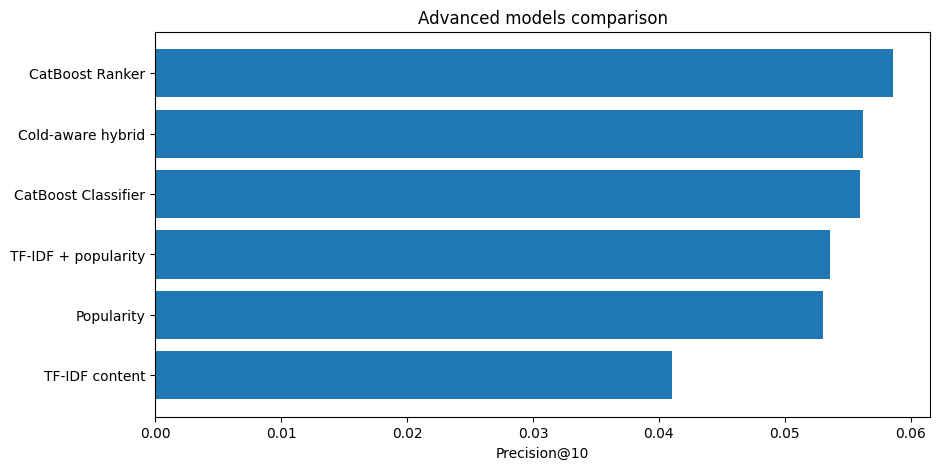

In [ ]:
plt.figure(figsize=(10, 5))

plot_df = advanced_results_df.sort_values(f"precision@{K}", ascending=True)

plt.barh(plot_df["model"], plot_df[f"precision@{K}"])
plt.xlabel(f"Precision@{K}")
plt.title("Advanced models comparison")
plt.show()

# Итоговый вывод по light advanced-ноутбуку

В light-версии была реализована облегчённая двухстадийная рекомендательная система.

На первом этапе формировались кандидаты из нескольких источников:

- Popularity;
- ALS;
- Cold-Aware Hybrid;
- TF-IDF/BERT content.

На втором этапе CatBoost выполнял финальное ранжирование кандидатов.

Из-за высокой вычислительной сложности CatBoost-модели обучались и оценивались на ограниченной подвыборке пользователей. Это допустимо для исследовательского прототипа, поскольку в предыдущем ноутбуке была проведена проверка устойчивости метрик на разных размерах evaluation sample.

Основной вывод: двухстадийная архитектура является перспективным развитием базовых гибридных моделей, так как позволяет объединять несколько источников сигналов и использовать признаки пары пользователь–объект для финального ранжирования.

,feature,importance
0,src_tfidf,0.133757
1,src_als,0.032432
2,item_popularity,0.020268
3,src_cold_aware,0.015024
4,src_popularity,0.009106
5,age_rating,0.000567
6,als_score,0.000497
7,tfidf_score,0.000394
8,n_user_history,0.000145
9,content_type,0.000065


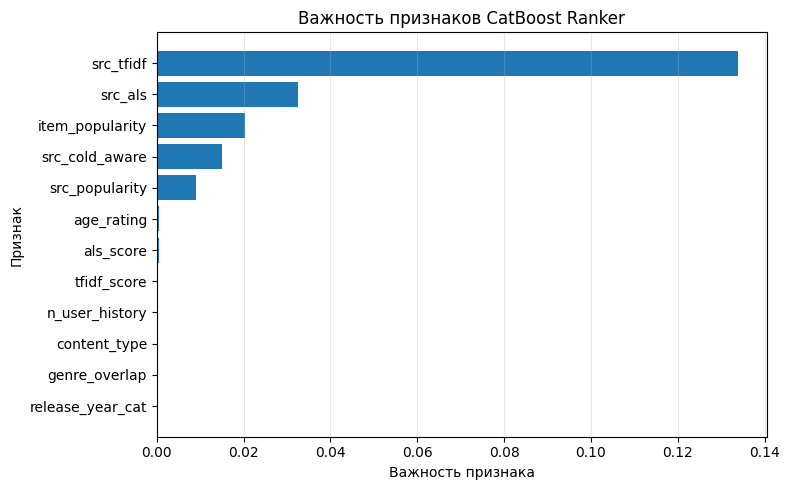

In [ ]:
if "CATBOOST_RANKER_AVAILABLE" in globals() and CATBOOST_RANKER_AVAILABLE:
    ranker_importances = cb_ranker.get_feature_importance(
        data=train_pool,
        type="LossFunctionChange"
    )

    ranker_fi = pd.DataFrame({
        "feature": feature_cols,
        "importance": ranker_importances
    })

    ranker_fi = (
        ranker_fi
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(ranker_fi)

    ranker_fi_plot = (
        ranker_fi
        .head(15)
        .sort_values("importance", ascending=True)
    )

    plt.figure(figsize=(8, 5))
    plt.barh(ranker_fi_plot["feature"], ranker_fi_plot["importance"])
    plt.xlabel("Важность признака")
    plt.ylabel("Признак")
    plt.title("Важность признаков CatBoost Ranker")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        "images/catboost_ranker_feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:
    print("CatBoost Ranker недоступен или не был обучен.")